# File-Based Photometry Fitting With Bandwagon

This notebook mirrors the DR16Q Bandwagon/SVI workflow, but the targets come from a local file instead of the DR16Q catalog.

Two input styles are supported:

- a source list with `source_id`, `ra`, `dec`, and `redshift` columns, which is then sent through Bandwagon/CDS XMatch
- a long-form photometry file with `source_id`, `filter_name`, `flux_mjy`, and `flux_err_mjy`; add `speclite_name` if the filter name is not one of the built-in mappings below

If explicit `ra`/`dec` columns are absent, the notebook tries to parse SDSS-style IDs such as `012254.62+010106.6` as J2000 coordinates. Redshifts are still required for fixed-redshift fitting; add a `redshift` column to the source file or fill `DEFAULT_REDSHIFT` for a temporary test.

In [1]:
from pathlib import Path
import re
import sys

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.table import Table
from tqdm.auto import tqdm

cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd
grahspj_src = project_root / "src"
bandwagon_src = project_root.parent / "bandwagon" / "src"
for path in (grahspj_src, bandwagon_src):
    if path.is_dir() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

from bandwagon import DEFAULT_CATALOGS, matches_to_photometry, xmatch_catalogs
from grahspj.config import AGNConfig, FilterSet, FitConfig, GalaxyConfig, InferenceConfig, LikelihoodConfig, Observation, PhotometryData
from grahspj.core import GRAHSPJ
from grahspj.mplstyle import style_path

plt.style.use(style_path())

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/nicho/miniconda3/envs/astro/lib/python3.11/site-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /home/nicho/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


## Settings

In [2]:
# Change this to the file you want to fit.
SOURCE_FILE = project_root / "table_7.csv"

# If SOURCE_FILE already contains long-form photometry, use it directly.
# If False, SOURCE_FILE is treated as a target list and Bandwagon will query GALEX/SDSS/AllWISE.
USE_PRECOMPUTED_PHOTOMETRY = False

# Use a fixed value only for a quick smoke test. Prefer a real per-source redshift column in SOURCE_FILE.
DEFAULT_REDSHIFT = None

SAMPLE_SIZE = 30
RANDOM_SEED = 20260519
SVI_STEPS = 2000
SVI_LEARNING_RATE = 5e-3
MIN_BANDS_TO_FIT = 5
N_FIT = SAMPLE_SIZE
MAX_MAG_ERR = 1.0

FILTER_SPECLITE_NAME = {
    "FUV_galex": "galex-fuv",
    "NUV_galex": "galex-nuv",
    "u_sdss": "sdss2010-u",
    "g_sdss": "sdss2010-g",
    "r_sdss": "sdss2010-r",
    "i_sdss": "sdss2010-i",
    "z_sdss": "sdss2010-z",
    "W1": "wise2010-W1",
    "W2": "wise2010-W2",
    "W3": "wise2010-W3",
    "W4": "wise2010-W4",
}

FILTER_ORDER = {name: i for i, name in enumerate(FILTER_SPECLITE_NAME)}

DEFAULT_CATALOGS

{'galex_ais': 'II/335/galex_ais',
 'sdss_dr16': 'V/154/sdss16',
 '2mass': 'II/246/out',
 '2mass_xsc': 'VII/233/xsc',
 'allwise': 'II/328/allwise',
 'legacy_dr8_north': 'VII/292/north',
 'legacy_dr8_south': 'VII/292/south'}

## Load Targets From File

In [3]:
def read_table(path):
    path = Path(path)
    if path.suffix.lower() in {".ecsv", ".csv", ".txt", ".dat"}:
        return Table.read(path, format="ascii.ecsv" if path.suffix.lower() == ".ecsv" else "ascii.csv")
    return Table.read(path)


def first_column(table, names):
    lower_to_name = {name.lower(): name for name in table.colnames}
    for name in names:
        if name.lower() in lower_to_name:
            return lower_to_name[name.lower()]
    return None


def parse_sdss_coord(value):
    text = str(value).strip().lstrip("J")
    match = re.fullmatch(r"(\d{2})(\d{2})(\d{2}(?:\.\d+)?)([+-])(\d{2})(\d{2})(\d{2}(?:\.\d+)?)", text)
    if match is None:
        raise ValueError(f"Cannot parse coordinates from source_id={value!r}")
    hh, mm, ss, sign, dd, dm, ds = match.groups()
    ra_deg = 15.0 * (float(hh) + float(mm) / 60.0 + float(ss) / 3600.0)
    dec_abs = float(dd) + float(dm) / 60.0 + float(ds) / 3600.0
    dec_deg = dec_abs if sign == "+" else -dec_abs
    return ra_deg, dec_deg


def as_float_array(values, default=np.nan):
    out = []
    for value in values:
        text = str(value).strip()
        if text == "" or text.lower() in {"nan", "none", "--"}:
            out.append(default)
        else:
            out.append(float(text))
    return np.asarray(out, dtype=float)


def safe_float(value, default=np.nan):
    try:
        text = str(value).strip()
        if text == "" or text.lower() in {"nan", "none", "--"}:
            return default
        return float(text)
    except Exception:
        return default


raw_table = read_table(SOURCE_FILE)
print(f"Read {len(raw_table):,} rows from {SOURCE_FILE}")
print("Columns:", raw_table.colnames)
raw_table[:5]

Read 6,007 rows from /home/nicho/GRAHSP/grahspj/table_7.csv
Columns: ['SDSS Name', 'RA', 'Dec', 'z', 'z_err', 'm_2500', 'm_2500_err', 'm_2500_uncorr', 'm_2500_uncorr_err', 'alpha_lambda', 'alpha_lambda_err', 'mu', 'mu_err', 'log_tau_UV_RF', 'log_tau_UV_RF_err', 'log_sigma_UV', 'log_sigma_UV_err', 'cov_log_sigma_UV_log_tau_UV_RF', 'f_host_2500A', 'f_host_2500A_err', 'f_BC', 'f_BC_err', 'f_lines', 'f_lines_err', 'f_FeII', 'f_FeII_err']


SDSS Name,RA,Dec,z,z_err,m_2500,m_2500_err,m_2500_uncorr,m_2500_uncorr_err,alpha_lambda,alpha_lambda_err,mu,mu_err,log_tau_UV_RF,log_tau_UV_RF_err,log_sigma_UV,log_sigma_UV_err,cov_log_sigma_UV_log_tau_UV_RF,f_host_2500A,f_host_2500A_err,f_BC,f_BC_err,f_lines,f_lines_err,f_FeII,f_FeII_err
str18,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
012254.62+010106.6,20.727605130014243,1.0185188322869363,0.19972552281965983,0.0002061619461115545,19.451966129562358,0.0421013635155151,20.72296318815539,0.0421013635155151,-2.52499122625417,0.1553552430974543,40.48246344476152,1.2152684222509949,2.0491990589664937,0.16927484496274603,-0.7401550792647809,0.1653518160183422,0.0004433161191415683,0.0,0.0,0.0001858526250764,0.0001025613256154,0.0330974379282788,0.0011046630869923086,0.0001412024295947,8.342155395377283e-05
023957.04+003242.8,39.98767909607699,0.5452348408572154,0.21675506655542218,0.0002604920995762357,20.575021428510066,0.0388913806583293,20.724329339815988,0.0388913806583293,-2.648933898684324,0.1431589079350159,40.131894280248225,1.2967935046270818,1.8707034586154914,0.24922673111825477,-0.5565117024208639,0.16960069692822005,-0.0023492391096062324,0.0,0.0,0.000181046531276,8.063797974050085e-05,0.052009354865351,0.0016005446523605943,0.0001437065617878,7.228499556461679e-05
235940.64+010008.7,359.91935722162907,1.002440428893257,0.22081915105999372,0.00028049055711349183,21.905404740042343,0.0019289657440957,22.167940540688303,0.0019289657440957,-1.6520531815006474,0.0038898436250795,41.68777749092345,1.0321181317380912,2.2597164756214103,0.18529998130351344,-0.49386683827049793,0.13431021593275141,0.0022418608363251923,0.0,0.0,0.0002508509704519,1.7614505867571408e-06,0.0658879498097017,0.00011171559723384022,0.0001771257755292,1.7225681469751802e-06
015238.52+010925.0,28.160529024564767,1.1569667232099976,0.23228837840280261,0.0002521238189557936,20.067868940111612,0.0028438874401714,21.027636818363582,0.0028438874401714,-2.1178173666859204,0.0037938232878542,41.048977862736436,1.1436012243924762,1.731561662934236,0.22571532912829573,-0.8123453716857426,0.14958222756581302,0.0013495008721690616,0.0,0.0,0.0003444622249892,1.1830099565342218e-05,0.0525999365311898,0.00010577622394682015,0.0001329741395468,2.821482336920871e-06
022951.18+010829.4,37.46328906827148,1.1415190736769767,0.24698603995449905,0.00023838396031496914,20.63023354485108,0.0245038637564452,20.859520531312995,0.0245038637564452,-2.7927011728241986,0.055669755982202,40.63961013716468,1.0171837824448164,1.7782237470162963,0.14890273106325091,-0.6497960264830178,0.12838523544699304,-0.000890866735217286,0.0,0.0,0.0002541279702168,4.537802446121651e-05,0.0456817517665576,0.0007087068021000255,0.0001993849220321,4.6771528595402926e-05


In [4]:
id_col = first_column(raw_table, ["source_id", "object_id", "id", "name", "sdss_name"])
if id_col is None:
    source_ids_all = np.asarray([f"source_{i:05d}" for i in range(len(raw_table))], dtype=object)
else:
    source_ids_all = np.asarray([str(value).strip() for value in raw_table[id_col]], dtype=object)

ra_col = first_column(raw_table, ["ra", "ra_deg", "raj2000"])
dec_col = first_column(raw_table, ["dec", "dec_deg", "dej2000"])
if ra_col is not None and dec_col is not None:
    ra_all = as_float_array(raw_table[ra_col])
    dec_all = as_float_array(raw_table[dec_col])
else:
    parsed = [parse_sdss_coord(source_id) for source_id in source_ids_all]
    ra_all = np.asarray([item[0] for item in parsed], dtype=float)
    dec_all = np.asarray([item[1] for item in parsed], dtype=float)

redshift_col = first_column(raw_table, ["redshift", "z", "z_spec", "z_dr16q"])
if redshift_col is not None:
    redshift_all = as_float_array(raw_table[redshift_col])
elif DEFAULT_REDSHIFT is not None:
    redshift_all = np.full(len(raw_table), float(DEFAULT_REDSHIFT))
else:
    redshift_all = np.full(len(raw_table), np.nan)

valid_targets = np.isfinite(ra_all) & np.isfinite(dec_all)
rng = np.random.default_rng(RANDOM_SEED)
valid_idx = np.flatnonzero(valid_targets)
sample_idx = rng.choice(valid_idx, size=min(SAMPLE_SIZE, valid_idx.size), replace=False)

source_ids = source_ids_all[sample_idx]
coords = SkyCoord(ra=ra_all[sample_idx] * u.deg, dec=dec_all[sample_idx] * u.deg, frame="icrs")
sample_meta = {
    str(source_id): {
        "source_id": str(source_id),
        "row_index": int(row_index),
        "ra": float(ra_all[row_index]),
        "dec": float(dec_all[row_index]),
        "redshift": float(redshift_all[row_index]),
    }
    for source_id, row_index in zip(source_ids, sample_idx)
}

print(f"Targets available: {valid_targets.sum():,}")
print(f"Sample size: {len(source_ids):,}")
print("First source IDs:", source_ids[:5].tolist())
if not np.all(np.isfinite(redshift_all[sample_idx])):
    print("Warning: at least one sampled target has no redshift. Add a redshift column or set DEFAULT_REDSHIFT before fitting.")

Targets available: 6,007
Sample size: 30
First source IDs: ['source_00091', 'source_01231', 'source_04727', 'source_05602', 'source_05556']


## Build Photometry

In [5]:
required_phot_cols = {"source_id", "filter_name", "flux_mjy", "flux_err_mjy"}
has_long_form_photometry = required_phot_cols.issubset(set(raw_table.colnames))

if USE_PRECOMPUTED_PHOTOMETRY:
    if not has_long_form_photometry:
        raise ValueError(f"USE_PRECOMPUTED_PHOTOMETRY=True requires columns {sorted(required_phot_cols)}")
    photometry = raw_table.copy()
    if "speclite_name" not in photometry.colnames:
        photometry["speclite_name"] = [FILTER_SPECLITE_NAME.get(str(name), "") for name in photometry["filter_name"]]
    if "psf_fwhm_arcsec" not in photometry.colnames:
        photometry["psf_fwhm_arcsec"] = np.full(len(photometry), np.nan)
    supported = np.asarray([str(value).strip() != "" for value in photometry["speclite_name"]], dtype=bool)
    finite = np.isfinite(as_float_array(photometry["flux_mjy"])) & np.isfinite(as_float_array(photometry["flux_err_mjy"]))
    positive = (as_float_array(photometry["flux_mjy"]) > 0.0) & (as_float_array(photometry["flux_err_mjy"]) > 0.0)
    selected_ids = set(np.asarray(source_ids, dtype=str))
    selected = np.asarray([str(value) in selected_ids for value in photometry["source_id"]], dtype=bool)
    photometry = photometry[supported & finite & positive & selected]
else:
    # This performs CDS XMatch requests for the sampled targets.
    matches = xmatch_catalogs(coords, source_id=source_ids)
    for key, table in matches.items():
        print(f"{key:10s}: {len(table):6d} matched rows; columns={table.colnames[:12]}")
    photometry = matches_to_photometry(matches, max_mag_err=MAX_MAG_ERR)

print(f"Long-form photometry rows: {len(photometry):,}")
if len(photometry):
    filters, filter_counts = np.unique(np.asarray(photometry["filter_name"], dtype=str), return_counts=True)
    print("Rows by filter:")
    for name, count in zip(filters, filter_counts):
        print(f"  {name:10s} {count:5d}")
photometry[:12]

galex_ais :     10 matched rows; columns=['angDist', 'source_id', 'ra', 'dec', 'RAJ2000', 'DEJ2000', 'name', 'objid', 'phID', 'Cat', 'RAfdeg', 'DEfdeg']
sdss_dr16 :    960 matched rows; columns=['angDist', 'source_id', 'ra', 'dec', 'objID', 'RA_ICRS', 'DE_ICRS', 'errHalfMaj', 'errHalfMin', 'errPosAng', 'mode', 'class']
2mass     :      0 matched rows; columns=['angDist', 'source_id', 'ra', 'dec', '2MASS', 'RAJ2000', 'DEJ2000', 'errHalfMaj', 'errHalfMin', 'errPosAng', 'Jmag', 'Hmag']
2mass_xsc :      0 matched rows; columns=['angDist', 'source_id', 'ra', 'dec', '_RAJ2000', '_DEJ2000', 'recno', '2MASX', 'All', 'RAJ2000', 'DEJ2000', 'r3sig']
allwise   :     20 matched rows; columns=['angDist', 'source_id', 'ra', 'dec', 'AllWISE', 'RAJ2000', 'DEJ2000', 'eeMaj', 'eeMin', 'eePA', 'W1mag', 'W2mag']
legacy_dr8_north:      2 matched rows; columns=['angDist', 'source_id', 'ra', 'dec', 'id', 'RAdeg', 'DEdeg', 'release', 'brickid', 'objid', 'type', 'pstar']
legacy_dr8_south:     29 matched rows; c

source_id,catalog,band,filter_name,speclite_name,mag,mag_err,mag_system,flux_mjy,flux_err_mjy,psf_fwhm_arcsec,match_distance_arcsec
str12,str9,str3,str9,str11,float64,float64,str4,float64,float64,float64,float64
source_00082,galex_ais,FUV,FUV_galex,galex-fuv,20.909400939941406,0.3156999945640564,ab,0.015713244670170323,0.004568947075004792,4.3,0.610136
source_00082,galex_ais,NUV,NUV_galex,galex-nuv,20.332000732421875,0.16290000081062317,ab,0.02674397489738089,0.004012570929633092,5.3,0.610136
source_00091,galex_ais,NUV,NUV_galex,galex-nuv,21.01569938659668,0.2962000072002411,ab,0.014247756828931491,0.0038869346502605822,5.3,1.55591
source_00158,galex_ais,NUV,NUV_galex,galex-nuv,22.03499984741211,0.34790000319480896,ab,0.005572195047652892,0.0017854858909419867,5.3,0.889631
source_00599,galex_ais,NUV,NUV_galex,galex-nuv,20.931900024414062,0.18410000205039978,ab,0.015390978770866382,0.002609730808327772,5.3,1.834212
source_00697,galex_ais,FUV,FUV_galex,galex-fuv,21.709199905395508,0.42500001192092896,ab,0.007522224430747156,0.002944495595457859,4.3,1.605397
source_00697,galex_ais,NUV,NUV_galex,galex-nuv,21.727800369262695,0.33660000562667847,ab,0.007394453823177642,0.0022924290334798954,5.3,1.605397
source_00774,galex_ais,NUV,NUV_galex,galex-nuv,21.17009925842285,0.334199994802475,ab,0.012359091443485586,0.0038042466283016983,5.3,1.935069
source_01010,galex_ais,NUV,NUV_galex,galex-nuv,22.366100311279297,0.4059000015258789,ab,0.004107580887267181,0.0015356097375244465,5.3,2.535156


Sources with >= 5 bands and redshift: 30
Will fit: 30
First fit source bands: [np.str_('FUV_galex'), np.str_('NUV_galex'), np.str_('u_sdss'), np.str_('g_sdss'), np.str_('r_sdss'), np.str_('i_sdss'), np.str_('z_sdss'), np.str_('W1'), np.str_('W2'), np.str_('W3'), np.str_('W4')]


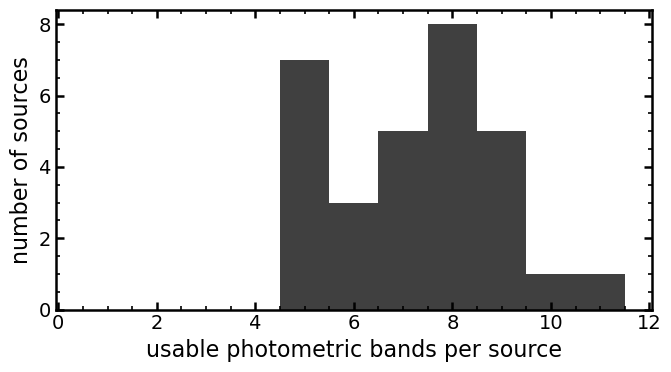

In [6]:
phot_source_ids = np.asarray(photometry["source_id"], dtype=str) if len(photometry) else np.asarray([], dtype=str)
unique_ids, counts = np.unique(phot_source_ids, return_counts=True)
source_band_sets = {
    sid: set(np.asarray(photometry[phot_source_ids == sid]["filter_name"], dtype=str))
    for sid in unique_ids
}


def source_priority(source_id):
    bands = source_band_sets[str(source_id)]
    return ("W4" in bands, "W3" in bands, len(bands))


fit_source_ids = [sid for sid, count in zip(unique_ids, counts) if count >= MIN_BANDS_TO_FIT]
fit_source_ids = [sid for sid in fit_source_ids if np.isfinite(sample_meta.get(str(sid), {}).get("redshift", np.nan))]
fit_source_ids = sorted(fit_source_ids, key=source_priority, reverse=True)[:N_FIT]

print(f"Sources with >= {MIN_BANDS_TO_FIT} bands and redshift: {len(fit_source_ids):,}")
print(f"Will fit: {len(fit_source_ids):,}")
if fit_source_ids:
    first_bands = sorted(source_band_sets[fit_source_ids[0]], key=lambda name: FILTER_ORDER.get(name, 999))
    print("First fit source bands:", first_bands)

if len(counts):
    plt.figure(figsize=(7, 4))
    plt.hist(counts, bins=np.arange(0.5, max(counts) + 1.5, 1.0), color="0.25")
    plt.xlabel("usable photometric bands per source")
    plt.ylabel("number of sources")
    plt.tight_layout()

## Build Fit Configs

In [7]:
dsps_ssp_fn = project_root / "tempdata.h5"
assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"


def rows_for_source(source_id):
    mask = np.asarray(photometry["source_id"], dtype=str) == str(source_id)
    rows = photometry[mask]
    order = np.argsort([FILTER_ORDER.get(str(name), 999) for name in rows["filter_name"]])
    return rows[order]


def build_fit_config(source_id, rows):
    meta = sample_meta[str(source_id)]
    if not np.isfinite(meta["redshift"]):
        raise ValueError(f"Missing redshift for {source_id}. Add a redshift column or set DEFAULT_REDSHIFT.")

    filter_names = [str(name) for name in rows["filter_name"]]
    fluxes = np.asarray(rows["flux_mjy"], dtype=float)
    errors = np.asarray(rows["flux_err_mjy"], dtype=float)
    errors = np.maximum(errors, 0.03 * fluxes)

    psf = []
    if "psf_fwhm_arcsec" in rows.colnames:
        psf = [safe_float(value) for value in rows["psf_fwhm_arcsec"]]
    else:
        psf = [np.nan] * len(rows)

    return FitConfig(
        observation=Observation(
            object_id=str(source_id),
            redshift=float(meta["redshift"]),
            fit_redshift=False,
            ra=float(meta["ra"]),
            dec=float(meta["dec"]),
        ),
        photometry=PhotometryData(
            filter_names=filter_names,
            fluxes=fluxes.tolist(),
            errors=errors.tolist(),
            is_upper_limit=[False] * len(rows),
            psf_fwhm_arcsec=psf,
        ),
        filters=FilterSet(
            speclite_names={str(row["filter_name"]): str(row["speclite_name"]) for row in rows},
            use_grahsp_database=False,
        ),
        galaxy=GalaxyConfig(dsps_ssp_fn=str(dsps_ssp_fn), n_wave=768),
        agn=AGNConfig(agn_type=1),
        likelihood=LikelihoodConfig(
            systematics_width=0.08,
            variability_uncertainty=True,
            use_host_capture_model=True,
        ),
        inference=InferenceConfig(
            map_steps=SVI_STEPS,
            learning_rate=SVI_LEARNING_RATE,
            seed=RANDOM_SEED,
        ),
        prior_config={
            "log_stellar_mass": {"loc": 10.5, "scale": 1.25},
            "fracAGN_5100": {"loc": 0.75, "scale": 0.2},
            "ebv_gal": {"scale": 0.2},
            "ebv_agn": {"scale": 0.2},
        },
    )


example_rows = rows_for_source(fit_source_ids[0]) if fit_source_ids else None
example_cfg = build_fit_config(fit_source_ids[0], example_rows) if fit_source_ids else None
print(example_cfg)

FitConfig(observation=Observation(object_id='source_02095', redshift=1.4086784404307906, fit_redshift=False, redshift_err=0.0, ra=22.961889, dec=-0.450505, apply_mw_deredden=False), photometry=PhotometryData(filter_names=['FUV_galex', 'NUV_galex', 'u_sdss', 'g_sdss', 'r_sdss', 'i_sdss', 'z_sdss', 'W1', 'W2', 'W3', 'W4'], fluxes=[0.005247910544436835, 0.022502250546937372, 0.043654252296493876, 0.05166851943425889, 0.05701986140510925, 0.06121051353332503, 0.05639316963845639, 0.21043448405989654, 0.37721619680075064, 1.5021134835744716, 4.689882834314297], errors=[0.0018318981444718622, 0.0027440349650567804, 0.0015278679357435554, 0.0015500555830277665, 0.0017105958421532775, 0.0018363154059997508, 0.003376101741826369, 0.007365058015108348, 0.015634303669859087, 0.15356824069682798, 1.0107727513556706], is_upper_limit=[False, False, False, False, False, False, False, False, False, False, False], psf_fwhm_arcsec=[4.3, 5.3, 1.53, 1.44, 1.32, 1.26, 1.29, 6.08, 6.84, 7.36, 11.99], apertu

## Fit With SVI

In [ ]:
partial_output_dir = project_root / "notebook_outputs" / "10_file_photometry_bandwagon_svi"
partial_output_dir.mkdir(parents=True, exist_ok=True)
partial_summary_path = partial_output_dir / "partial_fit_summary.ecsv"
partial_failures_path = partial_output_dir / "partial_failed_fits.ecsv"


def table_rows_as_dicts(path):
    if not path.exists():
        return []
    return [dict(row) for row in Table.read(path)]


def save_partial_fit_tables():
    if fit_summaries:
        Table(rows=fit_summaries).write(partial_summary_path, overwrite=True)
    if failed_fits:
        Table(rows=failed_fits).write(partial_failures_path, overwrite=True)


fit_summaries = table_rows_as_dicts(partial_summary_path)
failed_fits = table_rows_as_dicts(partial_failures_path)
completed_source_ids = {str(row["source_id"]) for row in fit_summaries}
failed_source_ids = {str(row["source_id"]) for row in failed_fits}
attempted_source_ids = completed_source_ids | failed_source_ids
remaining_fit_source_ids = [sid for sid in fit_source_ids if str(sid) not in attempted_source_ids]
fitters = []  # collect successful fitter objects for later inspection/plotting
example_fitter = None

if attempted_source_ids:
    print(
        f"Resuming from partial files: {len(completed_source_ids):,} successes and "
        f"{len(failed_source_ids):,} failures already saved."
    )
print(f"Partial summaries will be written to {partial_summary_path}")
print(f"Partial failures will be written to {partial_failures_path}")

for source_id in tqdm(remaining_fit_source_ids, desc="SVI fits"):
    rows = rows_for_source(source_id)
    cfg = build_fit_config(source_id, rows)
    fitter = GRAHSPJ(cfg)
    try:
        map_result = fitter.fit_map(
            steps=SVI_STEPS,
            learning_rate=SVI_LEARNING_RATE,
            progress_bar=False,
        )
        summary = fitter.summary()
        loss = np.asarray(map_result.get('losses', []), dtype=float)
        fit_summaries.append(
            {
                'source_id': str(source_id),
                'redshift': float(cfg.observation.redshift),
                'n_bands': len(rows),
                'final_loss': float(loss[-1]) if loss.size else np.nan,
                'log_stellar_mass_fit': summary.get('log_stellar_mass_fit', np.nan),
                'fracAGN_5100_median': summary.get('fracAGN_5100_median', np.nan),
                'log_agn_bol_luminosity_median': summary.get('log_agn_bol_luminosity_median', np.nan),
            }
        )
        # store fitter for multi-plotting and keep first example as before
        fitters.append(fitter)
        if example_fitter is None:
            example_fitter = fitter
        save_partial_fit_tables()
    except Exception as exc:
        failed_fits.append({
            'source_id': str(source_id),
            'redshift': float(cfg.observation.redshift),
            'n_bands': len(rows),
            'error': repr(exc),
        })
        save_partial_fit_tables()

save_partial_fit_tables()
fit_summary = Table(rows=fit_summaries)
print(f"Successful fits: {len(fit_summary):,}")
print(f"Failed fits: {len(failed_fits):,}")
fit_summary[:10]

Partial summaries will be written to /home/nicho/GRAHSP/grahspj/notebook_outputs/10_file_photometry_bandwagon_svi/partial_fit_summary.ecsv
Partial failures will be written to /home/nicho/GRAHSP/grahspj/notebook_outputs/10_file_photometry_bandwagon_svi/partial_failed_fits.ecsv


SVI fits:   0%|          | 0/30 [00:00<?, ?it/s]

E0520 09:05:14.879924    3543 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %erfc.2896 = f64[] add(%constant.4494, %constant.2477), metadata={op_name="jit(scan)/while/body/closed_call/jvp()/erfc" stack_frame_id=439}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0520 09:05:14.916671    3532 slow_operation_alarm.cc:140] The operation took 1.917101669s
Constant folding an instruction is taking > 1s:

  %erfc.2896 = f64[] add(%constant.4494, %constant.2477), metadata={op_name="jit(scan)/while/body/closed_call/jvp()/erfc" stack_frame_id=439}

This isn't necessarily a bug; constant-folding is inherently a trad

Plotting 1/1: source_05647


/home/nicho/GRAHSP/grahspj/src/grahspj/plotting.py:219: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


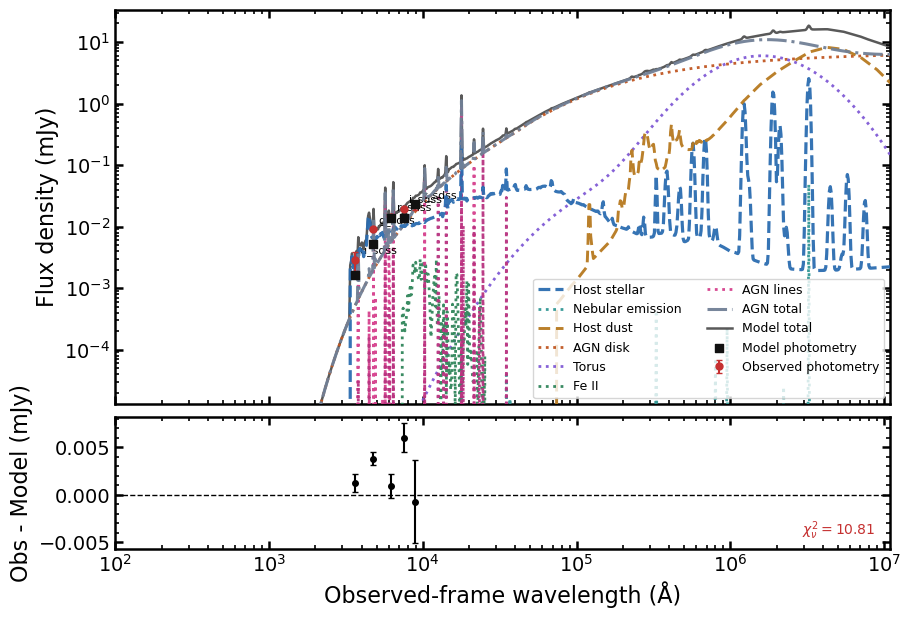

In [ ]:
# Plot all successful fits (one figure per source).
# This will call the existing `plot_sed` helper on each stored fitter.
if not globals().get("fitters"):
    print("No successful fits to plot.")
else:
    for i, fitter in enumerate(fitters, start=1):
        obj = fitter.config.observation.object_id
        print(f"Plotting {i}/{len(fitters)}: {obj}")
        try:
            pred = fitter.predict()
            fig = fitter.plot_sed(show=True)
            import matplotlib.pyplot as _plt
            _plt.show()
        except Exception as exc:
            print("Error plotting {obj}:", exc)

## Inspect One Fit

In [ ]:
phot_wave = np.asarray([flt.effective_wavelength for flt in example_fitter.context.filters], dtype=float)
model_flux = np.asarray(pred["pred_fluxes"][0], dtype=float)

print("filter, eff_wave_A, obs_mJy, err_mJy, model_mJy")
for name, wave, obs, err, model in zip(
    example_fitter.config.photometry.filter_names,
    phot_wave,
    example_fitter.config.photometry.fluxes,
    example_fitter.config.photometry.errors,
    model_flux,
):
    print((name, wave, obs, err, model))

filter, eff_wave_A, obs_mJy, err_mJy, model_mJy
('u_sdss', np.float64(3614.373573958611), 0.0028630338373272133, 0.0009361177946171183, np.float64(0.0016089495622308861))
('g_sdss', np.float64(4749.2299689145675), 0.008978962744038338, 0.00047138602768781544, np.float64(0.005153338289681014))
('r_sdss', np.float64(6205.832237243061), 0.014548768609423236, 0.000602996022947506, np.float64(0.013592286138210069))
('i_sdss', np.float64(7525.622462977008), 0.019571604820052987, 0.0009914362757295367, np.float64(0.013564533274343715))
('z_sdss', np.float64(8947.384740828762), 0.022429828969842087, 0.0038838234218063314, np.float64(0.023128293875427478))


## Save Optional Outputs

In [ ]:
# output_dir = project_root / "notebook_outputs" / "10_file_photometry_bandwagon_svi"
# output_dir.mkdir(parents=True, exist_ok=True)
# photometry.write(output_dir / "file_sample_bandwagon_photometry.ecsv", overwrite=True)
# fit_summary.write(output_dir / "file_sample_svi_summary.ecsv", overwrite=True)

## Notes

- The notebook does not touch `05_dr16q_bandwagon_svi.ipynb`.
- For file-driven Bandwagon matching, provide source coordinates either as `ra`/`dec` columns in degrees or SDSS-style coordinate IDs.
- For fitting, provide a real `redshift` column whenever possible. `DEFAULT_REDSHIFT` is only a quick local test hook.
- If your input file is already long-form photometry, set `USE_PRECOMPUTED_PHOTOMETRY=True` and make sure `filter_name` maps to a supported `speclite_name`.